In [1]:
cd ..

/home/mscs/congfeng4/GuidedStudy/Code/SCOIT


/public/congfeng4/miniconda3/envs/py39/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
pwd

'/home/mscs/congfeng4/GuidedStudy/Code/SCOIT'

In [3]:
import numpy as np
import pandas as pd
import time
import seaborn as sns
import hypernetx as hnx
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd
import time

from hgnn.hypergraph import load_graph, load_graph_metadata

In [4]:
df = load_graph_metadata(Path('./hypergraph'))
df.to_csv('./hypergraph/graph_metadata.csv', index=False)
df = pd.read_csv('./hypergraph/graph_metadata.csv')

Found dataset: sc_GEM
Found dataset: PEA_STA
Found dataset: sci_CAR
Found dataset: SCoPE2
Found dataset: SNARE_seq_adult_mouse
Found dataset: SNARE_seq_neonatal_mouse
Found dataset: CITE_seq


In [5]:
df.set_index('dataname')

,num_cells,num_genes,num_omics,num_nodes,num_edges
dataname,,,,,
sc_GEM,224,61,2,287,13664
PEA_STA,210,166,2,378,34860
sci_CAR,8837,100,2,8939,883700
SCoPE2,1490,5314,2,6806,7917860
SNARE_seq_adult_mouse,10309,100,2,10411,1030900
SNARE_seq_neonatal_mouse,5081,100,2,5183,508100
CITE_seq,8617,36293,2,44912,312736781


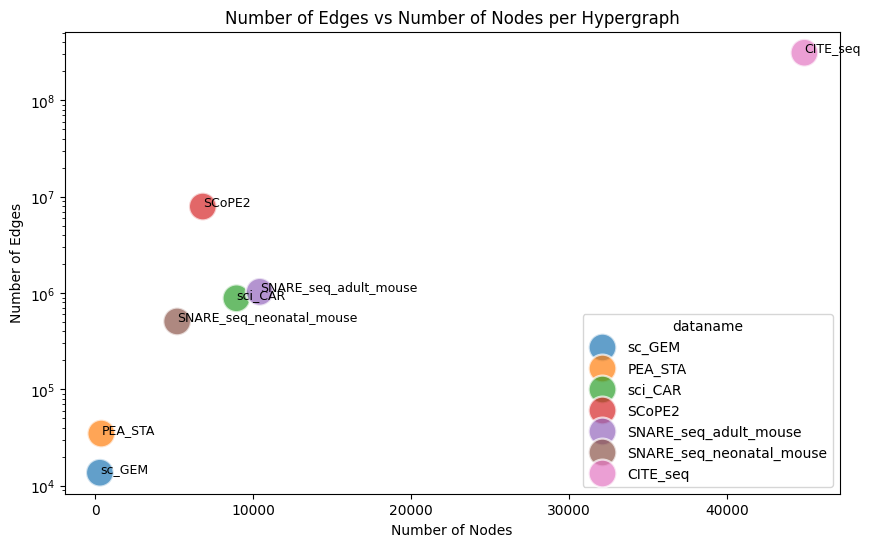

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot num_edges vs num_cells
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="num_nodes", y="num_edges", hue="dataname", s=400, alpha=0.7)
plt.yscale("log")
plt.title("Number of Edges vs Number of Nodes per Hypergraph")
plt.xlabel("Number of Nodes")
plt.ylabel("Number of Edges")

# Add text labels to each point
for idx, row in df.iterrows():
    # Place text slightly offset from the point to avoid overlap
    plt.text(
        x=row["num_nodes"] + 10,  # X-position (offset by 10 for readability)
        y=row["num_edges"] + 100, # Y-position (offset by 100)
        s=row["dataname"],        # Text to display (e.g., dataname)
        fontsize=9,
        color="black"
    )

plt.show()

In [7]:
df_long = df.melt(id_vars=['dataname'], value_vars=['num_nodes', 'num_edges', 'num_cells', 'num_genes', 'num_omics'],
                   var_name='type', value_name='count')

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'sc_GEM'),
  Text(1, 0, 'PEA_STA'),
  Text(2, 0, 'sci_CAR'),
  Text(3, 0, 'SCoPE2'),
  Text(4, 0, 'SNARE_seq_adult_mouse'),
  Text(5, 0, 'SNARE_seq_neonatal_mouse'),
  Text(6, 0, 'CITE_seq')])

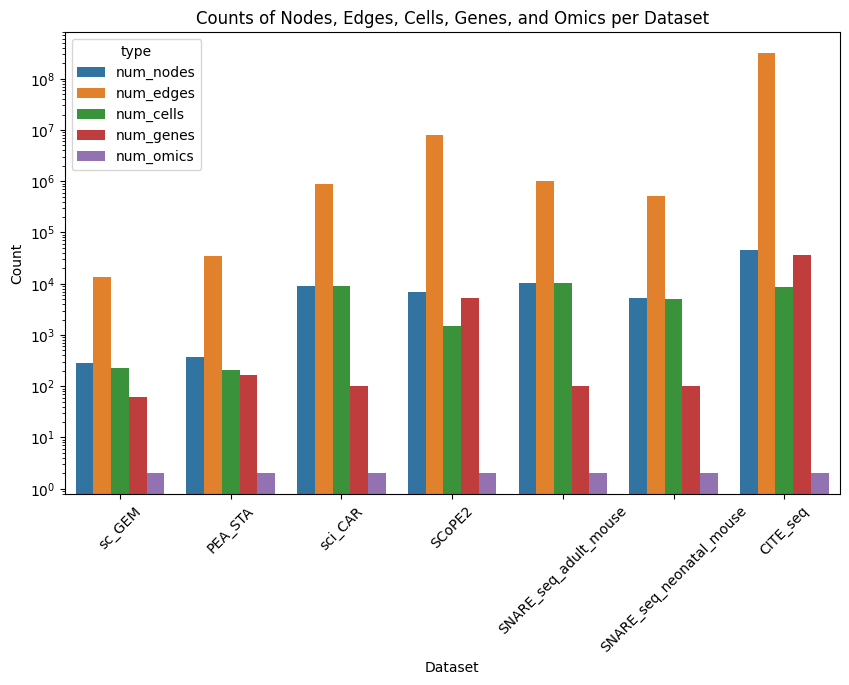

In [8]:
plt.figure(figsize=(10, 6))

sns.barplot(data=df_long, x='dataname', y='count', hue='type')
plt.yscale("log")
plt.xlabel("Dataset")
plt.ylabel("Count")
plt.title("Counts of Nodes, Edges, Cells, Genes, and Omics per Dataset")
plt.xticks(rotation=45)

In [9]:
g = load_graph(Path('./hypergraph/PEA_STA'))
print(g)

Load edges in 0.01 seconds.
Load nodes in 0.00 seconds.
Num nodes: 378, Num edges: 34860
Metadata: {'dataname': 'PEA_STA', 'num_cells': 210, 'num_genes': 166, 'num_omics': 2, 'num_nodes': 378, 'num_edges': 34860, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 168, 'raw_data': {'expr': './data/PEA_STA/expression_data.csv', 'protein': './data/PEA_STA/protein_data.csv'}, 'cell_key': 'Cells '}
HyperGraph(num_nodes=378, num_edges=34860)


In [10]:
g = load_graph(Path('./hypergraph/sc_GEM'))
print(g)

Load edges in 0.01 seconds.
Load nodes in 0.00 seconds.
Num nodes: 287, Num edges: 13664
Metadata: {'dataname': 'sc_GEM', 'num_cells': 224, 'num_genes': 61, 'num_omics': 2, 'num_nodes': 287, 'num_edges': 13664, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 63, 'raw_data': {'expr': './data/sc_GEM/expression_data.csv', 'methy': './data/sc_GEM/methylation_data.csv'}, 'cell_key': 'Cell ID'}
HyperGraph(num_nodes=287, num_edges=13664)


In [11]:
g = load_graph(Path('./hypergraph/sc_GEM'))
print(g)

Load edges in 0.01 seconds.
Load nodes in 0.00 seconds.
Num nodes: 287, Num edges: 13664
Metadata: {'dataname': 'sc_GEM', 'num_cells': 224, 'num_genes': 61, 'num_omics': 2, 'num_nodes': 287, 'num_edges': 13664, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 63, 'raw_data': {'expr': './data/sc_GEM/expression_data.csv', 'methy': './data/sc_GEM/methylation_data.csv'}, 'cell_key': 'Cell ID'}
HyperGraph(num_nodes=287, num_edges=13664)


In [12]:
g = load_graph(Path('./hypergraph/sci_CAR'))
print(g)

Load edges in 0.24 seconds.
Load nodes in 0.01 seconds.
Num nodes: 8939, Num edges: 883700
Metadata: {'dataname': 'sci_CAR', 'num_cells': 8837, 'num_genes': 100, 'num_omics': 2, 'num_nodes': 8939, 'num_edges': 883700, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 102, 'raw_data': {'atac': './data/sci_CAR/ATAC_lsi.csv', 'rna': './data/sci_CAR/RNA_pca.csv'}, 'cell_key': 'Unnamed: 0'}
HyperGraph(num_nodes=8939, num_edges=883700)


In [13]:
g = load_graph(Path('./hypergraph/SCoPE2'))
print(g)

Load edges in 1.79 seconds.
Load nodes in 0.00 seconds.
Num nodes: 6806, Num edges: 7917860
Metadata: {'dataname': 'SCoPE2', 'num_cells': 1490, 'num_genes': 5314, 'num_omics': 2, 'num_nodes': 6806, 'num_edges': 7917860, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 5316, 'raw_data': {'expr': './data/SCoPE2/expression_data.csv', 'protein': './data/SCoPE2/protein_data.csv'}, 'cell_key': 'Unnamed: 0'}
HyperGraph(num_nodes=6806, num_edges=7917860)


In [14]:
g = load_graph(Path('./hypergraph/sc_GEM'))
print(g)

Load edges in 0.01 seconds.
Load nodes in 0.00 seconds.
Num nodes: 287, Num edges: 13664
Metadata: {'dataname': 'sc_GEM', 'num_cells': 224, 'num_genes': 61, 'num_omics': 2, 'num_nodes': 287, 'num_edges': 13664, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 63, 'raw_data': {'expr': './data/sc_GEM/expression_data.csv', 'methy': './data/sc_GEM/methylation_data.csv'}, 'cell_key': 'Cell ID'}
HyperGraph(num_nodes=287, num_edges=13664)


In [15]:
g = load_graph(Path('./hypergraph/SNARE_seq_adult_mouse'))
print(g)

Load edges in 0.28 seconds.
Load nodes in 0.01 seconds.
Num nodes: 10411, Num edges: 1030900
Metadata: {'dataname': 'SNARE_seq_adult_mouse', 'num_cells': 10309, 'num_genes': 100, 'num_omics': 2, 'num_nodes': 10411, 'num_edges': 1030900, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 102, 'raw_data': {'atac': './data/SNARE_seq_adult_mouse/ATAC_lsi.csv', 'rna': './data/SNARE_seq_adult_mouse/RNA_pca.csv'}, 'cell_key': 'Unnamed: 0'}
HyperGraph(num_nodes=10411, num_edges=1030900)


In [16]:
g = load_graph(Path('./hypergraph/SNARE_seq_neonatal_mouse'))
print(g)

Load edges in 0.12 seconds.
Load nodes in 0.00 seconds.
Num nodes: 5183, Num edges: 508100
Metadata: {'dataname': 'SNARE_seq_neonatal_mouse', 'num_cells': 5081, 'num_genes': 100, 'num_omics': 2, 'num_nodes': 5183, 'num_edges': 508100, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 102, 'raw_data': {'atac': './data/SNARE_seq_neonatal_mouse/ATAC_lsi.csv', 'rna': './data/SNARE_seq_neonatal_mouse/RNA_pca.csv'}, 'cell_key': 'Unnamed: 0'}
HyperGraph(num_nodes=5183, num_edges=508100)


In [17]:
g = load_graph(Path('./hypergraph/CITE_seq'))
print(g)

Load edges in 4.57 seconds.
Load nodes in 0.02 seconds.
Num nodes: 44912, Num edges: 312736781
Metadata: {'dataname': 'CITE_seq', 'num_cells': 8617, 'num_genes': 36293, 'num_omics': 2, 'num_nodes': 44912, 'num_edges': 312736781, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 36295, 'raw_data': {'expr': './data/CITE_seq/expression_data.csv', 'protein': './data/CITE_seq/protein_data.csv'}, 'cell_key': 'cell ID'}
HyperGraph(num_nodes=44912, num_edges=312736781)
